In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("placement.csv")

In [5]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [6]:
df.shape

(200, 2)

Text(0, 0.5, 'Package (in lpa)')

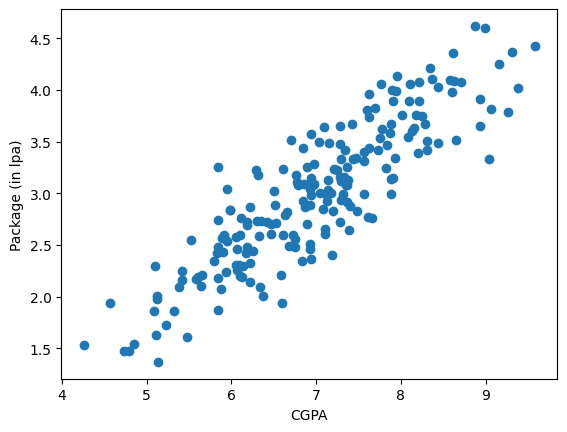

In [7]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel("CGPA")
plt.ylabel("Package (in lpa)")

In [8]:
X = df.iloc[:,0:1]
y = df.iloc[:,1]

In [9]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 2)

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
lr = LinearRegression()

In [13]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Text(0, 0.5, 'Package (in lpa)')

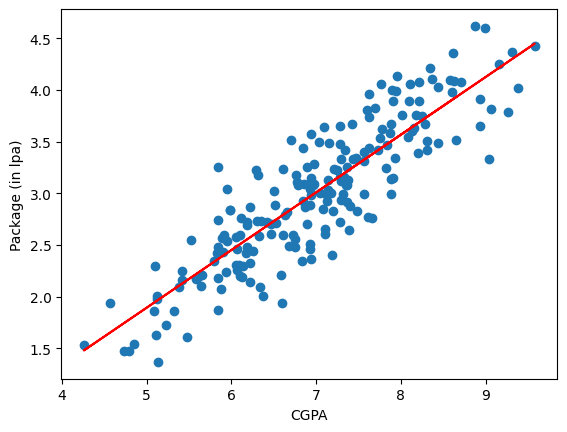

In [14]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train, lr.predict(X_train), color = 'red')
plt.xlabel("CGPA")
plt.ylabel("Package (in lpa)")

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [17]:
y_pred = lr.predict(X_test)

In [18]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [20]:
print("MAE", mean_absolute_error(y_test, y_pred))

MAE 0.2884710931878175


In [21]:
print("MSE", mean_squared_error(y_test, y_pred))

MSE 0.12129235313495527


In [23]:
print("RMSE",np.sqrt( mean_squared_error(y_test, y_pred)))

RMSE 0.34827051717731616


In [24]:
print("MSE",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

MSE 0.780730147510384


In [25]:
# Adjusted R2 Score
X_test.shape


(40, 1)

In [26]:
1-((1-r2)*(40-1)/(40-1-1))

0.7749598882343415

In [27]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.856527,3.26
1,5.12,0.341791,1.98
2,7.82,0.131826,3.25
3,7.42,0.522549,3.67
4,6.94,0.290640,3.57


In [28]:
new_df1.shape

(200, 3)

In [29]:
new_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cgpa            200 non-null    float64
 1   random_feature  200 non-null    float64
 2   package         200 non-null    float64
dtypes: float64(3)
memory usage: 4.8 KB


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


Text(0, 0.5, 'Package(in lpa)')

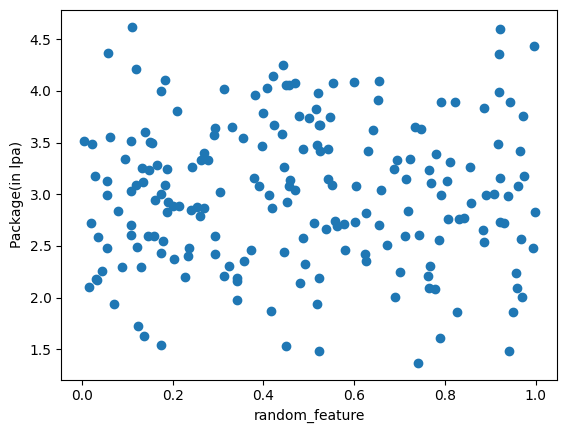

In [31]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')


In [32]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [34]:
lr = LinearRegression()

In [35]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
y_pred = lr.predict(X_test)

In [38]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)


R2 score 0.7789992356671598


In [39]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.7670532484059251

In [40]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]


In [41]:
new_df2.sample(5)

,cgpa,iq,package
58,6.92,4.09,3.09
26,8.31,4.42,3.42
100,7.95,4.34,4.14
175,7.04,3.80,3.50
61,5.48,2.01,1.61


Text(0, 0.5, 'Package(in lpa)')

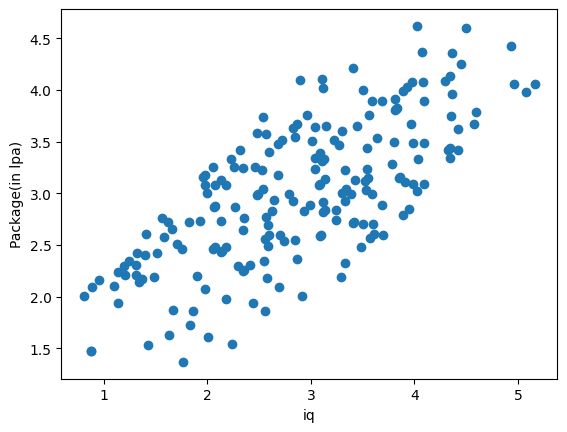

In [42]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [43]:
np.random.randint(-100,100)

56

In [44]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]


In [45]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [46]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [47]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.8227932358100344


In [48]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.8132144917997659